# Demo CNN con CIFAR-10

Este notebook muestra, paso a paso, cómo implementar una **red neuronal convolucional (CNN)** en Python para clasificar imágenes del dataset **CIFAR-10**.

## Objetivos de la demo

1. Entender cómo se representan las imágenes como tensores RGB.
2. Construir una arquitectura CNN simple.
3. Entrenar el modelo y monitorear su desempeño.
4. Evaluar el modelo sobre datos de prueba.
5. Visualizar predicciones, filtros y mapas de activación.

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Cargar el dataset CIFAR-10

CIFAR-10 contiene 60.000 imágenes RGB de tamaño **32x32**, distribuidas en 10 clases:

- avión
- auto
- pájaro
- gato
- ciervo
- perro
- rana
- caballo
- barco
- camión

In [3]:
# Carga del dataset CIFAR-10, el cual ya incluye una división predefinida de 50.000 imágenes para entrenamiento y 10.000 para prueba.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'avion', 'auto', 'pajaro', 'gato', 'ciervo',
    'perro', 'rana', 'caballo', 'barco', 'camion'
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)


## 3. Visualizar algunas imágenes

Una imagen RGB se representa como un tensor con forma:

`(alto, ancho, canales)`

En este caso, cada imagen tiene forma:

`(32, 32, 3)`

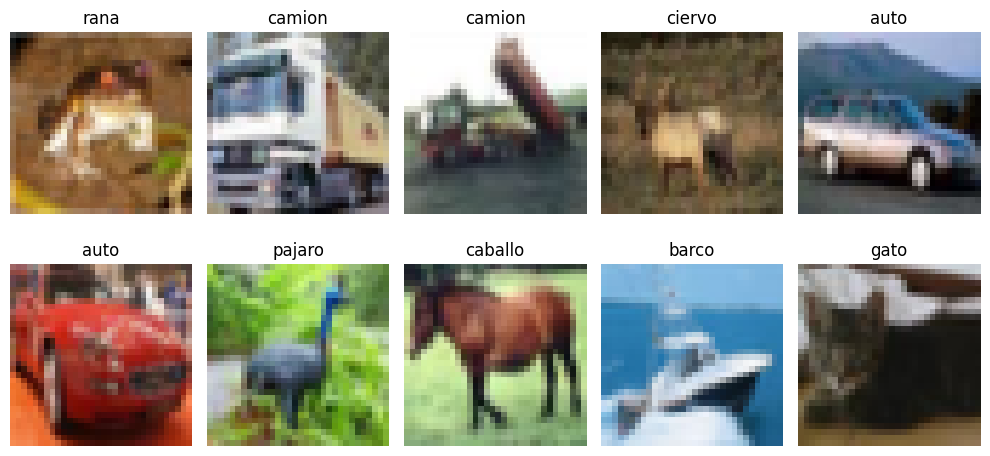

In [4]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Normalización

Los valores originales de los píxeles van de **0 a 255**.  
Es habitual normalizarlos a un rango entre **0 y 1** para facilitar el entrenamiento.

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Valor mínimo:", x_train.min())
print("Valor máximo:", x_train.max())

Valor mínimo: 0.0
Valor máximo: 1.0


## 5. Construir la CNN

Arquitectura utilizada:

- **Conv2D(32, 3x3)**: detecta patrones simples como bordes y texturas.
- **MaxPooling2D(2x2)**: reduce dimensionalidad.
- **Conv2D(64, 3x3)**: detecta patrones más complejos.
- **MaxPooling2D(2x2)**: vuelve a condensar la información.
- **Conv2D(128, 3x3)**: aprende patrones visuales más ricos.
- **Flatten()**: convierte el tensor 3D en un vector.
- **Dense(128)**: combina características aprendidas.
- **Dense(10, softmax)**: clasifica entre las 10 clases.

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

| Paso | Capa       | Operación            | Entrada      | Cálculo                             | Output Shape       | Parámetros                   |
| ---- | ---------- | -------------------- | ------------ | ----------------------------------- | ------------------ | ---------------------------- |
| 1    | Imagen     | Datos de entrada     | 32 × 32 × 3  | Imagen RGB (alto × ancho × canales) | (None, 32, 32, 3)  | 0                            |
| 2    | Conv2D     | 32 filtros 3×3       | 32 × 32 × 3  | (32 − 3 + 1) = 30                   | (None, 30, 30, 32) | (3×3×3 +1)×32 = **896**      |
| 3    | MaxPooling | Pooling 2×2          | 30 × 30 × 32 | 30 / 2 = 15                         | (None, 15, 15, 32) | 0                            |
| 4    | Conv2D     | 64 filtros 3×3       | 15 × 15 × 32 | (15 − 3 + 1) = 13                   | (None, 13, 13, 64) | (3×3×32 +1)×64 = **18,496**  |
| 5    | MaxPooling | Pooling 2×2          | 13 × 13 × 64 | 13 / 2 ≈ 6                          | (None, 6, 6, 64)   | 0                            |
| 6    | Conv2D     | 128 filtros 3×3      | 6 × 6 × 64   | (6 − 3 + 1) = 4                     | (None, 4, 4, 128)  | (3×3×64 +1)×128 = **73,856** |
| 7    | Flatten    | Vectorización        | 4 × 4 × 128  | 4×4×128 = 2048                      | (None, 2048)       | 0                            |
| 8    | Dense      | Capa fully connected | 2048         | 2048×128 + 128                      | (None, 128)        | **262,272**                  |
| 9    | Dense      | Capa de salida       | 128          | 128×10 + 10                         | (None, 10)         | **1,290**                    |


## 6. Compilar el modelo

- **Loss**: `sparse_categorical_crossentropy`  
  Se usa porque es una clasificación multiclase y las etiquetas están como enteros.
- **Optimizer**: `adam`  
  Es una elección práctica para comenzar, porque suele converger bien.
- **Metric**: `accuracy`  
  Mide el porcentaje de predicciones correctas.

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Entrenar el modelo

- **epochs=10**: el modelo recorre 10 veces todo el conjunto de entrenamiento.
- **batch_size=64**: procesa 64 imágenes antes de actualizar los pesos.
- **validation_split=0.2**: reserva 20% del conjunto de entrenamiento para validación.

In [8]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 93ms/step - accuracy: 0.4340 - loss: 1.5501 - val_accuracy: 0.5235 - val_loss: 1.3249
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.5727 - loss: 1.1990 - val_accuracy: 0.6062 - val_loss: 1.1208
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 91ms/step - accuracy: 0.6374 - loss: 1.0265 - val_accuracy: 0.6481 - val_loss: 1.0117
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.6790 - loss: 0.9106 - val_accuracy: 0.6771 - val_loss: 0.9334
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 89ms/step - accuracy: 0.7164 - loss: 0.8146 - val_accuracy: 0.6778 - val_loss: 0.9398
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.7445 - loss: 0.7275 - val_accuracy: 0.7011 - val_loss: 0.8783
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7704 - loss: 0.6546 - val_accuracy: 0.6991 - val_loss: 0.8893
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.7964 - loss: 0.5807 - 

## 8. Visualizar curvas de entrenamiento

Estas curvas ayudan a detectar si el modelo:

- está aprendiendo
- se estanca
- empieza a sobreajustar

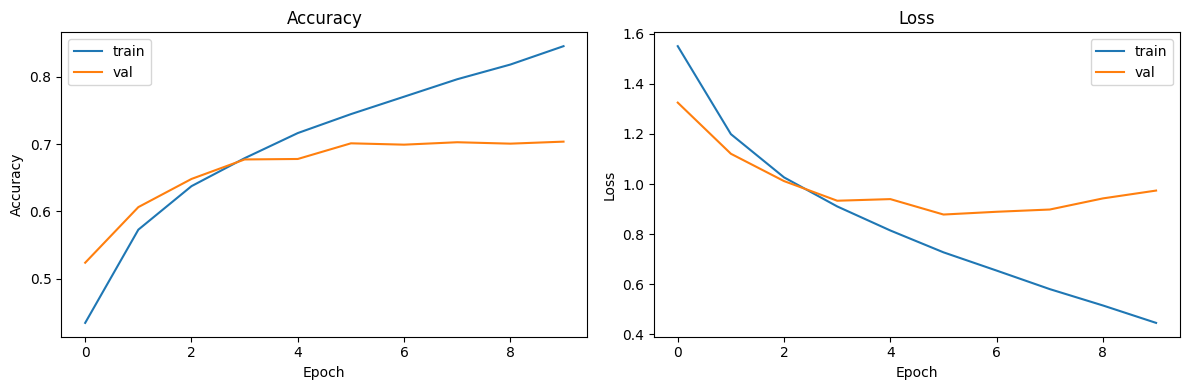

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 9. Evaluación en test

Ahora probamos el modelo con imágenes que no usó durante el entrenamiento.

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_acc:.4f}")

Loss en test: 0.9661
Accuracy en test: 0.7076


## 10. Predicciones sobre imágenes de prueba

Primero obtenemos probabilidades para las primeras 10 imágenes de `x_test`:

```python
predictions = model.predict(x_test[:10])
```

Luego usamos:

```python
pred_classes = np.argmax(predictions, axis=1)
```

para quedarnos con la clase de mayor probabilidad en cada imagen.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


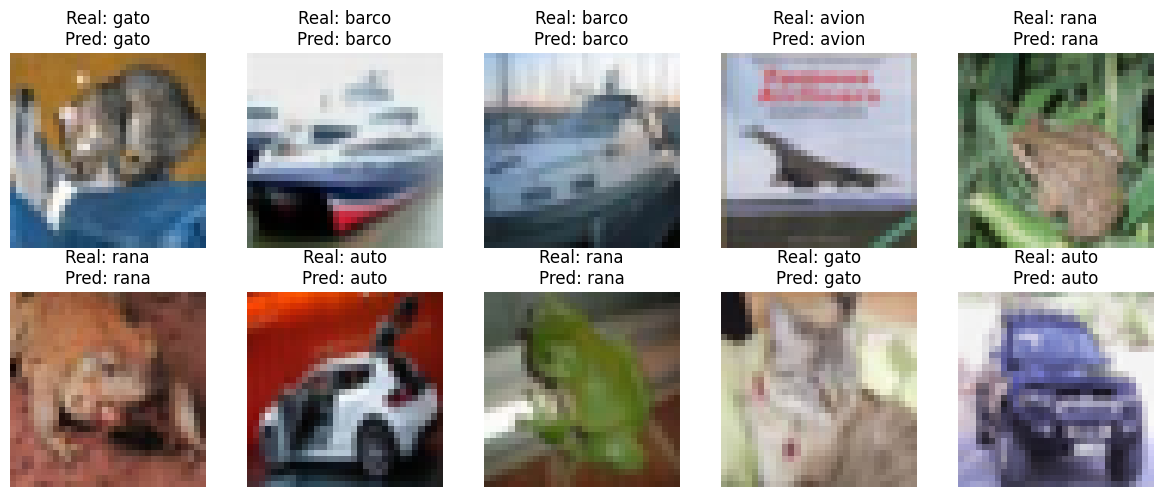

In [12]:
predictions = model.predict(x_test[:10])
pred_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i][0]]
    pred = class_names[pred_classes[i]]
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 11. Visualizar filtros de la primera capa convolucional

Aquí observamos los filtros aprendidos por la primera capa.  
Suelen capturar patrones básicos como bordes, diagonales y contrastes de color.

Shape de filtros: (3, 3, 3, 32)


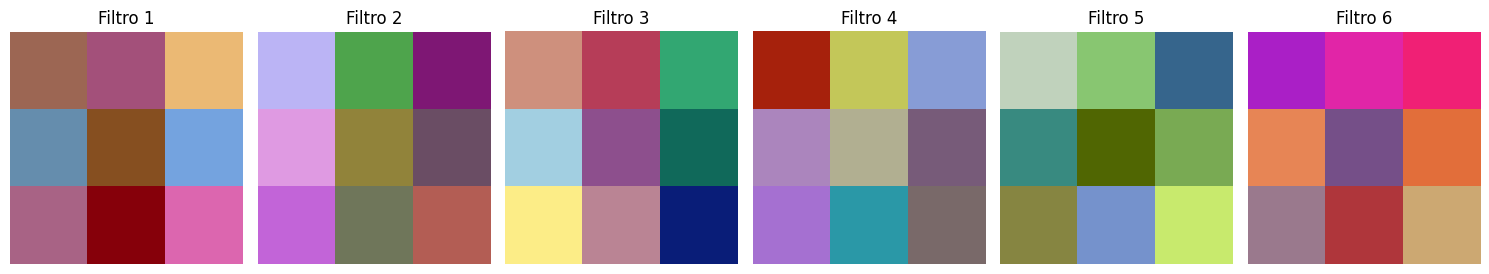

In [13]:
filters, biases = model.layers[0].get_weights()
print("Shape de filtros:", filters.shape)  # (3, 3, 3, 32)

f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

n_filters = 6
fig, axes = plt.subplots(1, n_filters, figsize=(15, 3))

for i in range(n_filters):
    f = filters_norm[:, :, :, i]
    axes[i].imshow(f)
    axes[i].set_title(f"Filtro {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 12. Visualizar mapas de activación (feature maps)

Esto permite ver qué partes de una imagen activan más ciertos filtros de la red.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Shape de feature maps: (1, 30, 30, 32)


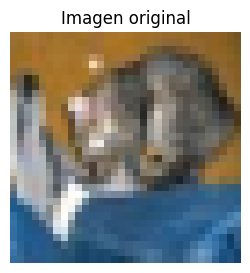

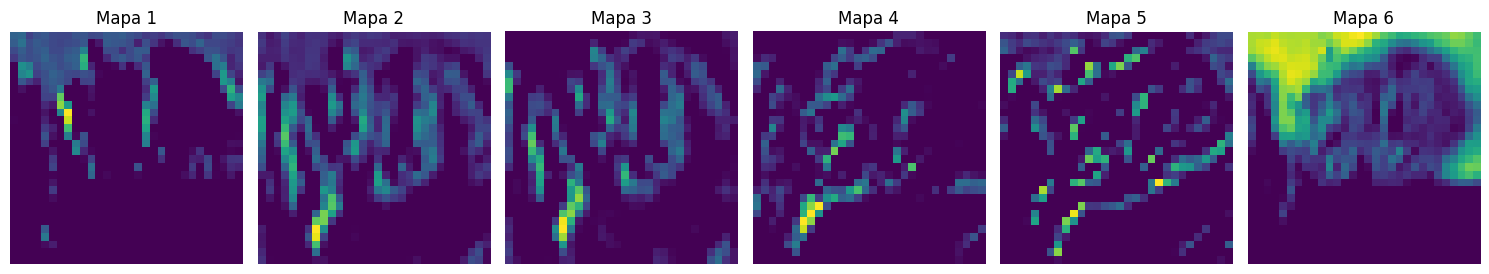

In [15]:
img = x_test[0]
img_batch = np.expand_dims(img, axis=0)

activation_model = Model(inputs=model.layers[0].input, outputs=model.layers[0].output)
feature_maps = activation_model.predict(img_batch)

print("Shape de feature maps:", feature_maps.shape)

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")
plt.show()

n_maps = 6
fig, axes = plt.subplots(1, n_maps, figsize=(15, 3))

for i in range(n_maps):
    axes[i].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[i].set_title(f"Mapa {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 13. Conclusiones

Con esta demo ya puedes mostrar que una CNN:

- recibe imágenes como tensores numéricos
- usa convoluciones para extraer características
- reduce dimensionalidad con pooling
- combina la información con capas densas
- genera probabilidades de clase con softmax

### Posibles mejoras futuras

- agregar `Dropout`
- usar `BatchNormalization`
- aplicar `Data Augmentation`
- entrenar más épocas
- usar arquitecturas más profundas como ResNet